In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler,StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_absolute_error, mean_squared_error
import random
from tensorflow.keras import models, layers, optimizers
from tensorflow.keras import callbacks

Loaded feat shape: (3433, 36)
Columns (sample): ['activePow', 'reactiveP', 'currentR', 'currentS', 'currentT', 'voltageR', 'voltageS', 'voltageT', 'voltageRS', 'voltageST', 'voltageTR', 'powerFactR', 'powerFactS', 'powerFactT', 'hour', 'dow', 'month', 'is_weekend', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'seoul_temp', 'seoul_temp_lag1', 'seoul_temp_lag24']
Uni cols (n): ['hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'is_weekend', 'is_holiday', 'seoul_temp', 'seoul_temp_lag1', 'seoul_temp_lag24', 'seoul_temp_lag168', 'seoul_temp_rmean24', 'seoul_temp_rmean168', 'activePow_lag1', 'activePow_lag24', 'activePow_lag168', 'activePow_rmean24', 'activePow_rstd24', 'activePow_rmean168', 'activePow_rstd168']
Multi cols (n): ['hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'is_weekend', 'is_holiday', 'seoul_temp', 'seoul_temp_lag1', 'seoul_temp_lag24', 'seoul_temp_lag168', 'seoul_temp_rmean24', 'seoul_temp_rmean168', 'activePow_lag1', 'activePow_lag24', 'activePow_lag168', 'activePow_rmean24'

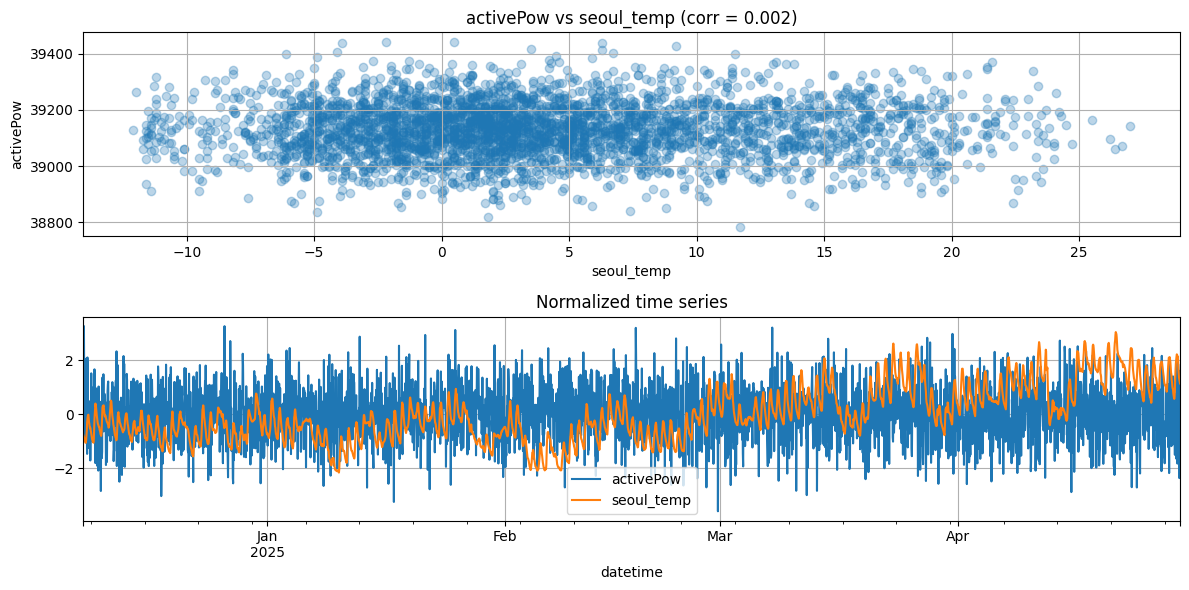

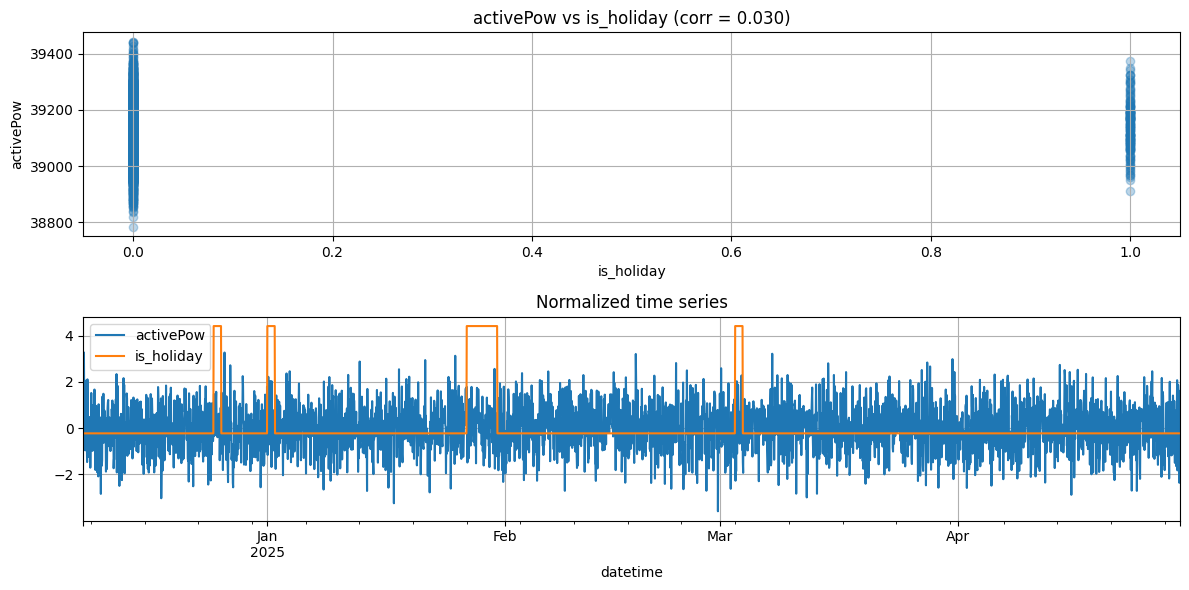


[Feature selection result]  (|corr| >= 0.3 => USE)
seoul_temp   | corr =  0.002 | DROP
is_holiday   | corr =  0.030 | DROP

[Final X_COLS_UNI used for APRIL model]
['hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'is_weekend', 'activePow_lag1', 'activePow_lag24', 'activePow_lag168', 'activePow_rmean24', 'activePow_rstd24', 'activePow_rmean168', 'activePow_rstd168']

[Final X_COLS_MULTI used for APRIL model]
n = 25
Epoch 1/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 9s 95ms/step - loss: 0.0359 - val_loss: 0.0221
Epoch 2/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 5s 80ms/step - loss: 0.0251 - val_loss: 0.0217
Epoch 3/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 5s 84ms/step - loss: 0.0244 - val_loss: 0.0217
Epoch 4/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 5s 91ms/step - loss: 0.0233 - val_loss: 0.0216
Epoch 5/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 5s 85ms/step - loss: 0.0233 - val_loss: 0.0216
Epoch 6/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 5s 80ms/step - loss: 0.0219 - val_loss: 0.0217
Epoch 7/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 5s 87ms/step - loss: 0.0225 

In [7]:
warnings.filterwarnings("ignore")

INPUT_PATH = r"D:/2025-2/BDA/공모전/sample data/rtu_data_1hour_v2.csv"
OUT_DIR    = r"D:/2025-2/BDA/공모전/sample data/output"
os.makedirs(OUT_DIR, exist_ok=True)

#하이퍼파라미터
SEED = 42
LOOKBACK = 24 * 7       
BATCH_SIZE = 32          
EPOCHS = 100          
LR = 1e-3
PATIENCE = 10            

MODULE_COL = "module(equipment)"
TARGET = "activePow"
SUM_COLS_CAND = ["activePow", "reactiveP"]
MEAN_COLS_CAND = [
    "currentR","currentS","currentT",
    "voltageR","voltageS","voltageT",
    "voltageRS","voltageST","voltageTR",
    "powerFactR","powerFactS","powerFactT",
]
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# 지표 정의
def mape(y_true, y_pred, eps=1e-9):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return np.mean(np.abs((y_true - y_pred) / (y_true + eps))) * 100

def mae(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return np.mean(np.abs(y_true - y_pred))

def rmse(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return np.sqrt(np.mean((y_true - y_pred) ** 2))


# 데이터 로드 + 공장 전체 집계
def load_and_aggregate_factory_hourly(input_path: str) -> pd.DataFrame:
    df = pd.read_csv(input_path)

    dt_candidates = ["datetime", "timestamp", "localtime", "id"]
    dt_col = next((c for c in dt_candidates if c in df.columns), None)
    if dt_col is None:
        raise KeyError(f"시간 컬럼을 찾지 못했습니다. 후보={dt_candidates}, 실제={df.columns.tolist()}")

    df["datetime"] = pd.to_datetime(df[dt_col], errors="coerce")
    df = df.dropna(subset=["datetime"]).copy()

    for c in df.columns:
        if c in ["datetime", dt_col, MODULE_COL]:
            continue
        df[c] = pd.to_numeric(df[c], errors="coerce")

    if "activePow" not in df.columns:
        for alt in ["activePower", "activePow(kW)", "activePower(kW)"]:
            if alt in df.columns:
                df["activePow"] = df[alt]
                break
    if "activePow" not in df.columns:
        raise KeyError(f"activePow 컬럼이 없습니다. 실제 컬럼={df.columns.tolist()}")

    sum_cols  = [c for c in SUM_COLS_CAND if c in df.columns]
    mean_cols = [c for c in MEAN_COLS_CAND if c in df.columns]

    agg = {c: "sum" for c in sum_cols}
    agg.update({c: "mean" for c in mean_cols})

    if MODULE_COL in df.columns:
        df_total = (
            df.groupby("datetime", as_index=False)
              .agg(agg)
              .sort_values("datetime")
              .set_index("datetime")
              .sort_index()
        )
    else:
        keep_cols = ["datetime"] + list(agg.keys())
        df_total = (
            df[keep_cols]
            .sort_values("datetime")
            .set_index("datetime")
            .sort_index()
        )

    df_total = df_total.resample("1H").mean()
    for c in df_total.columns:
        if df_total[c].isna().any():
            df_total[c] = df_total[c].interpolate(method="time", limit_direction="both")

    return df_total


# 시간 관련 피처 생성
def make_time_features(df_total: pd.DataFrame) -> pd.DataFrame:
    feat = df_total.copy()
    feat["hour"] = feat.index.hour
    feat["dow"] = feat.index.dayofweek
    feat["month"] = feat.index.month
    feat["is_weekend"] = (feat["dow"] >= 5).astype(int)

    feat["hour_sin"] = np.sin(2*np.pi*feat["hour"]/24)
    feat["hour_cos"] = np.cos(2*np.pi*feat["hour"]/24)
    feat["dow_sin"]  = np.sin(2*np.pi*feat["dow"]/7)
    feat["dow_cos"]  = np.cos(2*np.pi*feat["dow"]/7)
    return feat

# 시퀀스 생성
def make_sequences(df_scaled: pd.DataFrame, x_cols: list, y_col: str, lookback: int):
    X_list, y_list, t_list = [], [], []
    X_mat = df_scaled[x_cols].values.astype(np.float32)
    y_vec = df_scaled[y_col].values.astype(np.float32)
    idx = df_scaled.index

    for i in range(lookback, len(df_scaled)):
        X_list.append(X_mat[i-lookback:i, :])
        y_list.append(y_vec[i])
        t_list.append(idx[i])

    return np.array(X_list), np.array(y_list), pd.DatetimeIndex(t_list)

# LSTM 모델 정의
def build_lstm(n_features: int):
    model = models.Sequential([
        layers.Input(shape=(LOOKBACK, n_features)),
        layers.LSTM(64, return_sequences=True),
        layers.Dropout(0.2),
        layers.LSTM(32),
        layers.Dropout(0.2),
        layers.Dense(16, activation="swish"),
        layers.Dense(1)
    ])
    model.compile(
        optimizer=optimizers.Adam(learning_rate=LR),
        loss="mse"
    )
    return model

# 파생 피처: lag / rolling
LAG_LIST = [1, 24, 168]
ROLL_WINDOWS = [24, 168]

def add_lag_rolling_features(feat: pd.DataFrame, target_col: str = TARGET):
    feat = feat.copy()
    # lag
    for l in LAG_LIST:
        feat[f"{target_col}_lag{l}"] = feat[target_col].shift(l)

    # rolling (shift 1로 현재값 포함 방지)
    shifted = feat[target_col].shift(1)
    for w in ROLL_WINDOWS:
        feat[f"{target_col}_rmean{w}"] = shifted.rolling(w, min_periods=1).mean()
        feat[f"{target_col}_rstd{w}"]  = shifted.rolling(w, min_periods=2).std()

    return feat

# 외부 피처: 서울 기온 + 공휴일
SEOUL_TEMP_PATH = r"D:/2025-2/BDA/공모전/sample data/seoul_temp.csv"

def add_seoul_temp(feat: pd.DataFrame, temp_path: str = SEOUL_TEMP_PATH):
    feat = feat.copy()
    temp = pd.read_csv(temp_path)

    if "datetime" not in temp.columns:
        raise ValueError("seoul_temp.csv에 'datetime' 컬럼이 필요합니다.")
    temp["datetime"] = pd.to_datetime(temp["datetime"], errors="coerce")
    temp = temp.dropna(subset=["datetime"]).sort_values("datetime")

    # 기온 컬럼 자동 탐색
    cand = [c for c in temp.columns if c.lower() in ["ta","temp","temperature","t","air_temperature","airtemp"]]
    if len(cand) == 0:
        num_cols = temp.select_dtypes(include="number").columns.tolist()
        if len(num_cols) == 0:
            raise ValueError("seoul_temp.csv에서 기온(숫자형) 컬럼을 찾지 못했습니다.")
        temp_col = num_cols[0]
    else:
        temp_col = cand[0]

    temp = temp[["datetime", temp_col]].rename(columns={temp_col: "seoul_temp"}).set_index("datetime")

    feat = feat.join(temp, how="left")
    feat["seoul_temp"] = feat["seoul_temp"].interpolate(method="time").ffill().bfill()

    # 온도 lag/rolling(과거 정보만)
    for l in [1, 24, 168]:
        feat[f"seoul_temp_lag{l}"] = feat["seoul_temp"].shift(l)
    shifted = feat["seoul_temp"].shift(1)
    for w in [24, 168]:
        feat[f"seoul_temp_rmean{w}"] = shifted.rolling(w, min_periods=1).mean()

    return feat

def add_korea_holidays(feat: pd.DataFrame):
    feat = feat.copy()
    d = feat.index.normalize()

    holiday_dates = set(pd.to_datetime([
        "2024-12-25",
        "2025-01-01",
        "2025-01-27","2025-01-28","2025-01-29","2025-01-30",
        "2025-03-03",
        "2025-05-05","2025-05-06",
    ]).normalize())

    feat["is_holiday"] = d.isin(holiday_dates).astype(int)
    return feat

# 컬럼 세트(단변량/멀티변량) - lag/rolling + 외부피처 포함
def get_feature_columns(feat: pd.DataFrame):
    time_cols = ["hour_sin","hour_cos","dow_sin","dow_cos","is_weekend"]
    holiday_cols = ["is_holiday"]
    temp_cols = [
        "seoul_temp","seoul_temp_lag1","seoul_temp_lag24","seoul_temp_lag168",
        "seoul_temp_rmean24","seoul_temp_rmean168"
    ]

    lag_cols = [f"{TARGET}_lag{l}" for l in LAG_LIST]
    roll_cols = []
    for w in ROLL_WINDOWS:
        roll_cols += [f"{TARGET}_rmean{w}", f"{TARGET}_rstd{w}"]

    # 단변량: 시간 + 공휴일 + 기온 + target lag/rolling
    X_COLS_UNI = time_cols + holiday_cols + temp_cols + lag_cols + roll_cols

    # 다변량: 단변량 + 존재하는 계측값(시간특성/월/시간키 제외)
    base_exclude = set(X_COLS_UNI + [TARGET, "month", "hour", "dow"])
    extra = [c for c in feat.columns if c not in base_exclude]
    X_COLS_MULTI = X_COLS_UNI + extra

    return X_COLS_UNI, X_COLS_MULTI

# =========================
df_total = load_and_aggregate_factory_hourly(INPUT_PATH)

feat = make_time_features(df_total)
feat = add_seoul_temp(feat, SEOUL_TEMP_PATH)
feat = add_korea_holidays(feat)
feat = add_lag_rolling_features(feat, TARGET)

feat = feat.dropna().copy()

X_COLS_UNI, X_COLS_MULTI = get_feature_columns(feat)

print("Loaded feat shape:", feat.shape)
print("Columns (sample):", feat.columns.tolist()[:25])
print("Uni cols (n):", list(X_COLS_UNI))
print("Multi cols (n):", list(X_COLS_MULTI))
print("Month range:", feat.index.min(), "~", feat.index.max())

# ============================================================
# 외부 데이터 연관성 파악 및 사용 여부 결정
# ============================================================
CAND_FEATURES = ["seoul_temp", "is_holiday"]
THRESH = 0.3

corr_result = {}
for c in CAND_FEATURES:
    if c in feat.columns:
        corr_result[c] = feat[[TARGET, c]].corr().iloc[0, 1]
    else:
        corr_result[c] = np.nan

corr_df = pd.DataFrame.from_dict(corr_result, orient="index", columns=["pearson_corr"])
print("\n[Correlation with activePow]")
print(corr_df)

# 시각화: 산점도 + 정규화 시간추이
for c, corr in corr_result.items():
    if c not in feat.columns:
        continue

    fig, axes = plt.subplots(2, 1, figsize=(12, 6))

    axes[0].scatter(feat[c], feat[TARGET], alpha=0.3)
    axes[0].set_title(f"{TARGET} vs {c} (corr = {corr:.3f})")
    axes[0].set_xlabel(c)
    axes[0].set_ylabel(TARGET)
    axes[0].grid(True)

    tmp = feat[[TARGET, c]].copy()
    tmp = (tmp - tmp.mean()) / (tmp.std() + 1e-9)
    tmp.plot(ax=axes[1])
    axes[1].set_title("Normalized time series")
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()

USE_FEATURES = [c for c, corr in corr_result.items() if abs(corr) >= THRESH]

print("\n[Feature selection result]  (|corr| >= 0.3 => USE)")
for c in CAND_FEATURES:
    decision = "USE" if c in USE_FEATURES else "DROP"
    print(f"{c:12s} | corr = {corr_result[c]: .3f} | {decision}")

# 선택 결과를 4월 모델 입력 컬럼에 반영
X_COLS_UNI_SEL = X_COLS_UNI.copy()
X_COLS_MULTI_SEL = X_COLS_MULTI.copy()

# seoul_temp 계열 제거
if "seoul_temp" not in USE_FEATURES:
    X_COLS_UNI_SEL = [c for c in X_COLS_UNI_SEL if not c.startswith("seoul_temp")]
    X_COLS_MULTI_SEL = [c for c in X_COLS_MULTI_SEL if not c.startswith("seoul_temp")]

# is_holiday 제거
if "is_holiday" not in USE_FEATURES:
    X_COLS_UNI_SEL = [c for c in X_COLS_UNI_SEL if c != "is_holiday"]
    X_COLS_MULTI_SEL = [c for c in X_COLS_MULTI_SEL if c != "is_holiday"]

print("\n[Final X_COLS_UNI used for APRIL model]")
print(X_COLS_UNI_SEL)

print("\n[Final X_COLS_MULTI used for APRIL model]")
print(f"n = {len(X_COLS_MULTI_SEL)}")

# =========================
# 4월 평가용 학습/예측
# =========================
def run_april_eval_lstm(x_cols, tag, out_csv_name):
    """
    4월(2025-04) 평가용 LSTM:
      - train: 12,1,2
      - val  : 3
      - pred : 4
    """
    train_months = [12, 1, 2]
    val_month = 3
    pred_month = 4

    sub = feat.loc[feat["month"].isin(train_months + [val_month, pred_month])].copy()

    # 스케일러는 train+val에만 fit (누수 방지)
    scaler_x = MinMaxScaler()
    scaler_y = MinMaxScaler()
    tv = sub.loc[sub["month"].isin(train_months + [val_month])].copy()

    scaler_x.fit(tv[x_cols])
    scaler_y.fit(tv[[TARGET]])

    scaled = sub.copy()
    scaled.loc[:, x_cols] = scaler_x.transform(sub[x_cols])
    scaled.loc[:, TARGET] = scaler_y.transform(sub[[TARGET]])

    X, y, t_seq = make_sequences(scaled, x_cols, TARGET, LOOKBACK)

    months = sub.loc[t_seq, "month"].values
    tr = np.isin(months, train_months)
    va = (months == val_month)
    pr = (months == pred_month)

    X_tr, y_tr = X[tr], y[tr]
    X_va, y_va = X[va], y[va]

    model = build_lstm(n_features=X.shape[-1])
    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss", patience=PATIENCE, restore_best_weights=True
        )
    ]
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=LR), loss="mse")
    model.fit(
        X_tr, y_tr,
        validation_data=(X_va, y_va),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        verbose=1,
        callbacks=callbacks
    )

    # 4월 예측 (스케일 복원)
    yhat_s = model.predict(X[pr], verbose=0).reshape(-1, 1)
    ytrue_s = y[pr].reshape(-1, 1)

    yhat = scaler_y.inverse_transform(yhat_s).reshape(-1)
    y_true = scaler_y.inverse_transform(ytrue_s).reshape(-1)

    print("="*70)
    print(f"[APRIL EVAL] {tag}")
    print("\n")
    print(f"X cols (n={len(x_cols)}): {list(x_cols)}")
    print("\n")
    print(f"MAPE: {mape(y_true, yhat):.4f}%")
    print(f"MAE : {mae(y_true, yhat):.4f} kW")
    print(f"RMSE: {rmse(y_true, yhat):.4f} kW")
    print("="*70)

    out = pd.DataFrame({
        "datetime": t_seq[pr].strftime("%Y-%m-%d %H:%M:%S"),
        "y_true_kW": y_true,
        "y_pred_kW": yhat
    })

    total_power = out["y_pred_kW"].sum()
    out["pred_sum_kW"] = total_power
    out["bill_est"] = total_power * 180
    out["carbon_est"] = total_power * 0.424

    out_path = os.path.join(OUT_DIR, out_csv_name)
    out.to_csv(out_path, index=False, encoding="utf-8-sig")
    print(f"저장 완료: {out_path}")

    return model, scaler_x, scaler_y, out

# =========================
# 실행: 4월 UNI + MULTI 
# =========================
model_apr_multi, sx_apr_multi, sy_apr_multi, april_multi_out = run_april_eval_lstm(
    x_cols=X_COLS_MULTI_SEL,
    tag="MULTIVARIATE (selected temp/holiday by corr)",
    out_csv_name="pred_2025_04_multivariate_selected.csv"
)

model_apr_uni, sx_apr_uni, sy_apr_uni, april_uni_out = run_april_eval_lstm(
    x_cols=X_COLS_UNI_SEL,
    tag="UNIVARIATE (selected temp/holiday by corr)",
    out_csv_name="pred_2025_04_univariate_selected.csv"
)


In [11]:
# ============================================================
# 12~3 train, 4 val 로 학습 → 5월 y_pred만 rolling 생성
# - 외부변수(seoul_temp, is_holiday) 사용 안 함
# ============================================================

time_cols = ["hour_sin","hour_cos","dow_sin","dow_cos","is_weekend"]
lag_cols  = [f"{TARGET}_lag{l}" for l in LAG_LIST]
roll_cols = []

for w in ROLL_WINDOWS:
    roll_cols += [f"{TARGET}_rmean{w}", f"{TARGET}_rstd{w}"]

X_COLS_UNI_NOEXT = time_cols + lag_cols + roll_cols

missing = [c for c in X_COLS_UNI_NOEXT if c not in feat.columns]
if missing:
    raise KeyError(f"feat에 필요한 컬럼이 없습니다: {missing}\n"
                   f"-> 위에서 add_lag_rolling_features, make_time_features가 실행됐는지 확인하세요.")

print("X_COLS_UNI_NOEXT n =", len(X_COLS_UNI_NOEXT))

#12-4월 학습 함수
def train_12to3_val4_lstm(x_cols, tag="UNI_NO_EXTERNAL"):
    train_months = [12, 1, 2, 3]
    val_month = 4

    sub = feat.loc[feat["month"].isin(train_months + [val_month])].copy()

    # scaler는 train에만 fit
    scaler_x = MinMaxScaler()
    scaler_y = MinMaxScaler()

    tr = sub.loc[sub["month"].isin(train_months)].copy()
    va = sub.loc[sub["month"] == val_month].copy()

    scaler_x.fit(tr[x_cols])
    scaler_y.fit(tr[[TARGET]])

    scaled = sub.copy()
    scaled.loc[:, x_cols] = scaler_x.transform(sub[x_cols])
    scaled.loc[:, TARGET] = scaler_y.transform(sub[[TARGET]])

    X, y, t_seq = make_sequences(scaled, x_cols, TARGET, LOOKBACK)
    months = sub.loc[t_seq, "month"].values

    tr_mask = np.isin(months, train_months)
    va_mask = (months == val_month)

    X_tr, y_tr = X[tr_mask], y[tr_mask]
    X_va, y_va = X[va_mask], y[va_mask]

    model = build_lstm(n_features=X.shape[-1])
    es = tf.keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=PATIENCE, restore_best_weights=True
    )

    model.fit(
        X_tr, y_tr,
        validation_data=(X_va, y_va),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        verbose=1,
        callbacks=[es]
    )

    # 4월 val 성능 출력(선택)
    yhat_s = model.predict(X_va, verbose=0).reshape(-1, 1)
    ytrue_s = y_va.reshape(-1, 1)

    yhat = scaler_y.inverse_transform(yhat_s).reshape(-1)
    ytrue = scaler_y.inverse_transform(ytrue_s).reshape(-1)

    print("="*70)
    print(f"[TRAIN 12~3 | VAL 4] {tag}")
    print(f"X cols n = {len(x_cols)}")
    print("="*70)
    print(f"X cols n = {list(x_cols)}")
    print("="*70)
    print(f"VAL MAPE: {mape(ytrue, yhat):.4f}%")
    print(f"VAL MAE : {mae(ytrue, yhat):.4f} kW")
    print(f"VAL RMSE: {rmse(ytrue, yhat):.4f} kW")
    print("="*70)

    return model, scaler_x, scaler_y

# 5월 rolling 예측 함수
def predict_may_rolling_y_pred_only(model, scaler_x, scaler_y, x_cols, out_csv_name):
    may_start = pd.Timestamp("2025-05-01 00:00:00")
    may_end   = pd.Timestamp("2025-05-28 23:00:00")
    may_idx = pd.date_range(may_start, may_end, freq="1H")

    # 2-1) 초기 LOOKBACK 윈도우는 4월 말 실제 feat에서 가져옴 (이미 lag/rolling 포함)
    hist_feat = feat.loc[feat.index < may_start]

    if len(hist_feat) < LOOKBACK:
        raise ValueError(
            f"LOOKBACK 초기화 실패: 5월 이전 데이터가 {LOOKBACK}개 미만입니다. "
            f"(현재 {len(hist_feat)}개)"
        )
    init_df = hist_feat.iloc[-LOOKBACK:].copy()
    
    # 2-2) rolling 업데이트용 히스토리(y 실제 + 예측)
    need_hist = max(LAG_LIST + ROLL_WINDOWS)
    hist_y = feat.loc[feat.index < may_start, TARGET].iloc[-need_hist:].tolist()
    if len(hist_y) < need_hist:
        raise ValueError("초기 hist_y 길이가 부족합니다. 데이터 기간을 확인하세요.")

    feature_window = init_df[x_cols].values.astype(float).tolist()

    preds = []

    # 시간 피처 row 생성
    def time_row(ts: pd.Timestamp):
        hour = ts.hour
        dow = ts.dayofweek
        is_weekend = 1 if dow >= 5 else 0
        return {
            "hour_sin": np.sin(2*np.pi*hour/24),
            "hour_cos": np.cos(2*np.pi*hour/24),
            "dow_sin":  np.sin(2*np.pi*dow/7),
            "dow_cos":  np.cos(2*np.pi*dow/7),
            "is_weekend": is_weekend
        }

    for ts in may_idx:
        row = time_row(ts)

        # lag
        for l in LAG_LIST:
            row[f"{TARGET}_lag{l}"] = hist_y[-l]

        # rolling (직전값 기반)
        for w in ROLL_WINDOWS:
            vals = hist_y[-w:]
            row[f"{TARGET}_rmean{w}"] = float(np.mean(vals))
            row[f"{TARGET}_rstd{w}"]  = float(np.std(vals, ddof=1)) if len(vals) >= 2 else 0.0

        # window 갱신
        feature_window.append([row[c] for c in x_cols])
        if len(feature_window) > LOOKBACK:
            feature_window.pop(0)

        X_flat = np.array(feature_window, dtype=np.float32)  # (LOOKBACK, n_features)
        X_scaled = scaler_x.transform(X_flat).reshape(1, LOOKBACK, len(x_cols))

        yhat_s = model.predict(X_scaled, verbose=0).reshape(-1, 1)
        yhat = float(scaler_y.inverse_transform(yhat_s)[0, 0])

        preds.append((ts.strftime("%Y-%m-%d %H:%M:%S"), yhat))

        # 다음 step을 위한 업데이트
        hist_y.append(yhat)
        if len(hist_y) > 1000:
            hist_y = hist_y[-1000:]

    out = pd.DataFrame(preds, columns=["datetime", "hourly_pow"])
    total_power = out["hourly_pow"].sum()
    out["agg_pow"] = total_power
    out["may_bill"] = total_power * 180
    out["may_carbon"] = total_power * 0.424
    
    out_path = os.path.join(OUT_DIR, out_csv_name)
    out.to_csv(out_path, index=False, encoding="utf-8-sig")
    print("5월 예측 저장 완료")
    return out
    
model_may, sx_may, sy_may = train_12to3_val4_lstm(
    x_cols=X_COLS_UNI_NOEXT,
    tag="UNI (time + lag/rolling only)"
)

may_out = predict_may_rolling_y_pred_only(
    model=model_may,
    scaler_x=sx_may,
    scaler_y=sy_may,
    x_cols=X_COLS_UNI_NOEXT,
    out_csv_name="submission_lstm.csv"
)

X_COLS_UNI_NOEXT n = 12
Epoch 1/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 12s 93ms/step - loss: 0.0348 - val_loss: 0.0223
Epoch 2/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 7s 81ms/step - loss: 0.0224 - val_loss: 0.0221
Epoch 3/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 7s 88ms/step - loss: 0.0217 - val_loss: 0.0221
Epoch 4/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 6s 74ms/step - loss: 0.0213 - val_loss: 0.0221
Epoch 5/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 6s 72ms/step - loss: 0.0214 - val_loss: 0.0221
Epoch 6/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 6s 76ms/step - loss: 0.0214 - val_loss: 0.0221
Epoch 7/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 7s 83ms/step - loss: 0.0213 - val_loss: 0.0221
Epoch 8/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 7s 83ms/step - loss: 0.0213 - val_loss: 0.0221
Epoch 9/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 6s 80ms/step - loss: 0.0214 - val_loss: 0.0221
Epoch 10/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 7s 88ms/step - loss: 0.0212 - val_loss: 0.0221
Epoch 11/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 6s 79ms/step - loss: 0.0211 - val_loss: 0.0221
Epoch 12/100
81/81 ━━━━━━━━